# FARGOpy
## Wrapping FRAGO3D

### What's in this notebook


This notebook demonstrates how to use the `FARGOpy` library to perform advanced calculations and analyses on simulation data from `FARGO3D`. The main focus is on calculating integrals over a general surface or volume and visualizing the results.

Key sections include:

- **Creating a Sphere Object**: Define a spherical surface for 3D analysis, specifying its radius, center, and subdivisions.

- **Analyzing Data**:
  - Create an `Analyzer` object to perform calculations on the simulation data.
  - Define custom integrand functions for specific analyses, such as calculating flux over a surface.

- **Performing Integrals**:
  - Calculate integrals over a surface or volume using the `Analyzer` object.
  - Use a user-defined integrand function to compute the desired quantity, such as flux or other physical properties.

- **Visualizing Results**:
  - Plot the calculated results as a function of time.
  - Highlight key metrics, such as the average value of the computed integral, for better interpretation.

This notebook serves as a practical guide for users to explore and analyze `FARGO3D` simulation data using `FARGOpy`, focusing on integral-based calculations and their visualization.

### Before starting

If you are in `Google Colab`, install the latest version of the package:

In [ ]:
# @title Install fargopy
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq fargopy

For this tutorial you will need the following external modules and tools:

In [ ]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

Running FARGOpy version 0.3.15


### Let's `FARGOpy`

First we need the data. Let's download a precomputed simulation. Check the list:

In [5]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB


Download, for instance, the 3D simulation of a disk with a Jovian planet:

In [6]:
fp.Simulation.download_precomputed('p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist


'/tmp/p3disoj'

Once download it, we need to connect a `Simulation` with the directory with the simulation results:

In [7]:
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Configuration variables and domains load into the object. See e.g. <sim>.vars


Now we load the data from `FARGO3D`simulation results for a visualization:

In [8]:
gasd = sim.load_field('gasdens',snapshot=10,type='scalar')


gasd_xz_slice,mesh0 = gasd.meshslice(slice='phi=0')
gasd_xy_slice,mesh1 = gasd.meshslice(slice='theta=1.56')

### Create the sphere object

In [10]:
sphere = fp.Sphere(radius=0.08, subdivisions=1, center=(1.0, 0.0, 0.0))

In [11]:
type(sphere)

fargopy.flux.Sphere

Visualize the sphere object

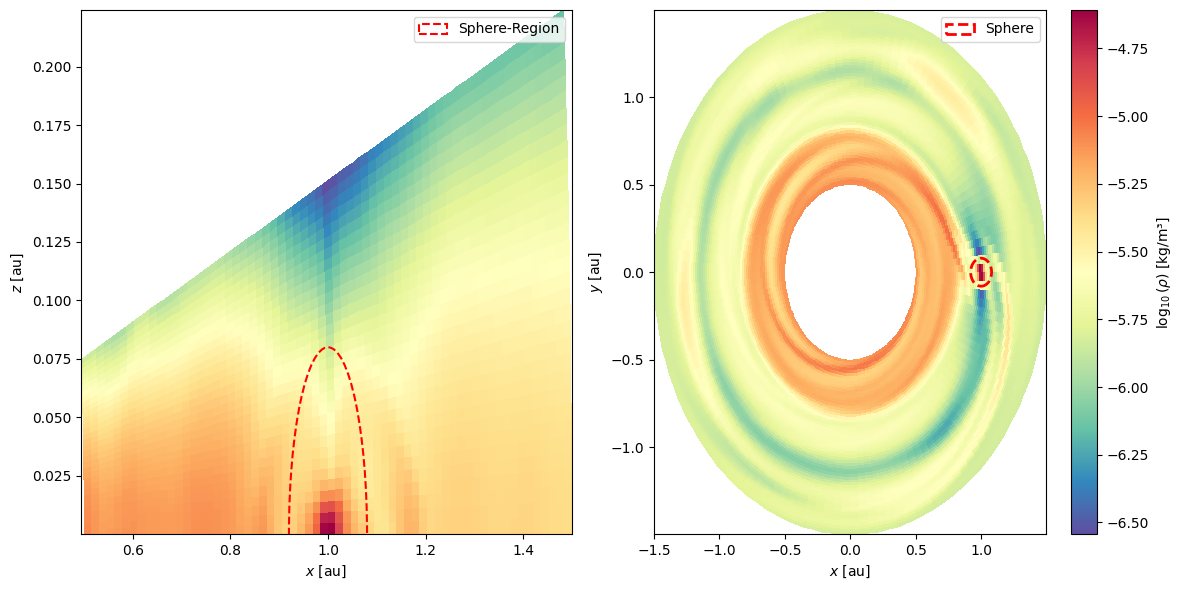

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

cmap = 'Spectral_r'

# Colormap of the logarithmic density for the XZ plane
ax = axs[0]
pc = ax.pcolormesh(
    mesh0.x * sim.UL / fp.AU,
    mesh0.z * sim.UL / fp.AU,
    np.log10(gasd_xz_slice * sim.URHO * 1e3),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$z$ [au]')

# Add a circle to the XZ plane
circle_xz = plt.Circle(
    (sphere.center[0], sphere.center[2]),  # Center in the XZ plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=1.5,
    label='Sphere-Region'
)
ax.add_artist(circle_xz)
ax.legend()

# Colormap of the logarithmic density for the XY plane
ax = axs[1]
pc = ax.pcolormesh(
    mesh1.x * sim.UL / fp.AU,
    mesh1.y * sim.UL / fp.AU,
    np.log10(gasd_xy_slice * sim.URHO * 1e3),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')

# Add a circle to the XY plane
circle_xy = plt.Circle(
    (sphere.center[0], sphere.center[1]),  # Center in the XY plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Sphere'
)
ax.add_artist(circle_xy)
ax.legend()

# Add colorbar
fig.colorbar(pc, ax=axs[1], label=r"$\log_{10}(\rho)$ [kg/m³]")

plt.tight_layout()
plt.show()

Create the `Analyzer` object


In [ ]:

sphere = fp.Sphere(
    radius=0.08, 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
    )


analyzer = fp.Analyzer(
    simulation=sim,
    surface=sphere,
    fields=['gasdens', 'gasv'],
    snapshots=(1, 10)
)



Loading 3D data.
Loading 3D data.


Calculating integral: 100%|██████████| 100/100 [02:10<00:00,  1.30s/it]


Define the integrand function, in this case flux over 3D surface:

In [ ]:

integrand = lambda gasdens, gasv: gasdens * np.einsum('ij,ij->i', gasv, sphere.normals)

Calculate the flux integral:

In [ ]:
flux = analyzer.calculate_integral(integrand=integrand, time_steps=50)

plot the results:

Text(1, 1, 'FARGOpy 0.3.15')

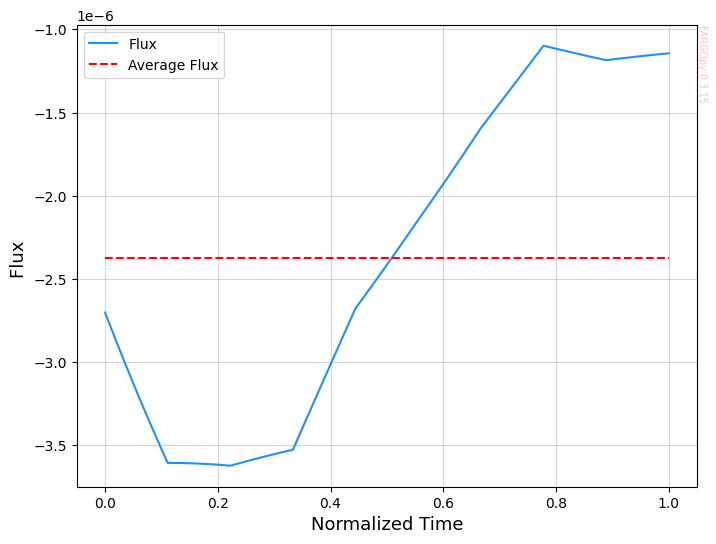

In [39]:

flux_averaged = np.mean(flux)


fig,axs = plt.subplots(1,1,figsize=(8,6))



# Colormap of the logaritmic density
axs.plot(np.linspace(0, 1, 100), flux, label='Flux', color='dodgerblue')
axs.hlines(y=flux_averaged, xmin=0, xmax=1, color='red', linestyle='--', label='Average Flux')
axs.set_xlabel('Normalized Time',size=13)
axs.set_ylabel('Flux ',size=13)
axs.legend()
axs.grid(alpha=0.5)
fp.Plot.fargopy_mark(axs)

